In [ ]:
%pip install pandas
import pandas as pd

train = pd.read_csv(
    "../data/raw/goemotions/train.tsv",
    sep="\t"
)

train.head()


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,My favourite food is anything I didn't have to cook myself.,27,eebbqej
0,"Now if he does off himself, everyone will thin...",27,ed00q6i
1,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
2,To make her feel threatened,14,ed7ypvh
3,Dirty Southern Wankers,3,ed0bdzj
4,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,26,edvnz26


In [4]:
print(train.columns)
print(train.shape)

Index(['My favourite food is anything I didn't have to cook myself.', '27',
       'eebbqej'],
      dtype='str')
(43409, 3)


In [5]:
dair = pd.read_csv(
    "../data/raw/dair_emotion/train.csv"
)

print(dair.columns)
print(dair.shape)

Index(['text', 'label'], dtype='str')
(16000, 2)


In [6]:
import pandas as pd

train = pd.read_csv("../data/raw/goemotions/train.tsv", sep="\t")

print(train.columns)
print(train.head())
print(train.shape)

Index(['My favourite food is anything I didn't have to cook myself.', '27',
       'eebbqej'],
      dtype='str')
  My favourite food is anything I didn't have to cook myself.  27  eebbqej
0  Now if he does off himself, everyone will thin...           27  ed00q6i
1                     WHY THE FUCK IS BAYLESS ISOING            2  eezlygj
2                        To make her feel threatened           14  ed7ypvh
3                             Dirty Southern Wankers            3  ed0bdzj
4  OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...           26  edvnz26
(43409, 3)


In [7]:
import pandas as pd

train = pd.read_csv(
    "../data/raw/goemotions/train.tsv",
    sep="\t",
    header=None,
    names=["text", "label", "id"]
)

print(train.head())
print(train.columns)
print(train.shape)

                                                text label       id
0  My favourite food is anything I didn't have to...    27  eebbqej
1  Now if he does off himself, everyone will thin...    27  ed00q6i
2                     WHY THE FUCK IS BAYLESS ISOING     2  eezlygj
3                        To make her feel threatened    14  ed7ypvh
4                             Dirty Southern Wankers     3  ed0bdzj
Index(['text', 'label', 'id'], dtype='str')
(43410, 3)


In [8]:
import pandas as pd

stats = {
    "samples": len(train),
    "unique_labels": train["label"].nunique(),
    "avg_text_length": train["text"].str.len().mean(),
    "max_text_length": train["text"].str.len().max(),
    "min_text_length": train["text"].str.len().min()
}

stats_df = pd.DataFrame([stats])

stats_df.to_csv(
    "../data/metadata/goemotions_stats.csv",
    index=False
)

stats_df

,samples,unique_labels,avg_text_length,max_text_length,min_text_length
0,43410,711,68.400875,703,2


In [9]:
dair = pd.read_csv(
    "../data/raw/dair_emotion/train.csv"
)

stats = {
    "samples": len(dair),
    "unique_labels": dair["label"].nunique(),
    "avg_text_length": dair["text"].str.len().mean(),
    "max_text_length": dair["text"].str.len().max(),
    "min_text_length": dair["text"].str.len().min()
}

pd.DataFrame([stats]).to_csv(
    "../data/metadata/dair_stats.csv",
    index=False
)


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


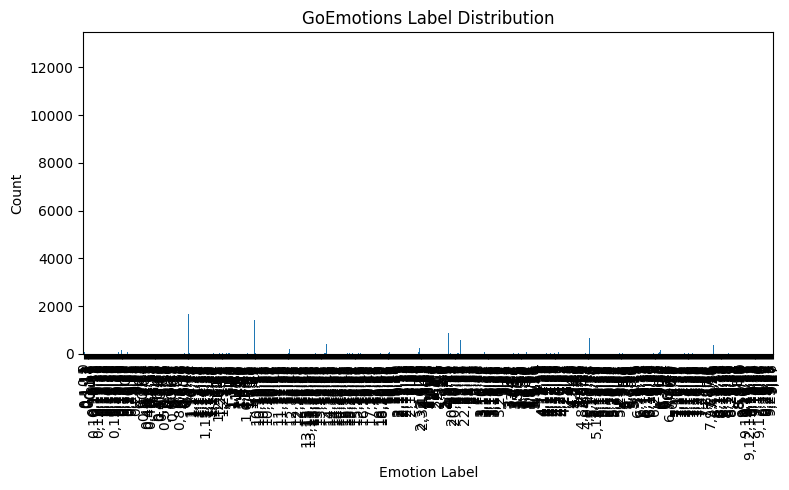

In [11]:
%pip install matplotlib
import matplotlib.pyplot as plt

label_counts = train["label"].value_counts().sort_index()

plt.figure(figsize=(8,5))
label_counts.plot(kind="bar")

plt.title("GoEmotions Label Distribution")
plt.xlabel("Emotion Label")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../figures/goemotions_distribution.png",dpi=300
)

plt.show()

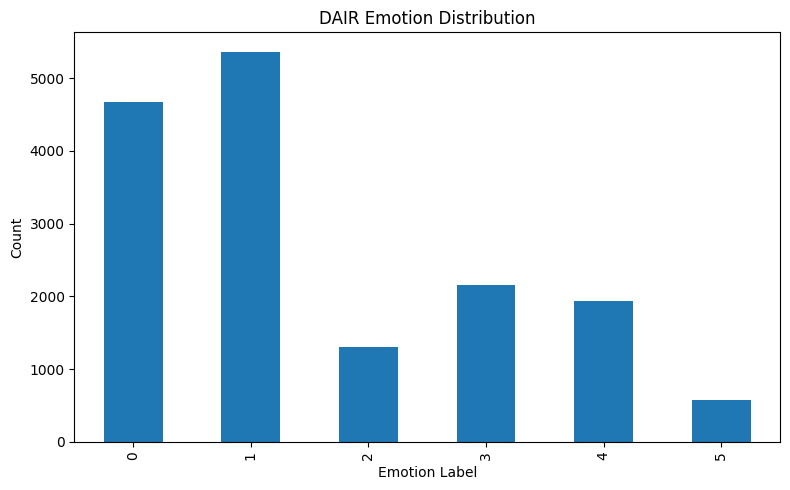

In [12]:
label_counts = dair["label"].value_counts().sort_index()

plt.figure(figsize=(8,5))
label_counts.plot(kind="bar")

plt.title("DAIR Emotion Distribution")
plt.xlabel("Emotion Label")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../figures/dair_distribution.png"
)

plt.show()

In [13]:
print(train["label"].value_counts())

label
27            12823
0              2710
4              1873
15             1857
1              1652
              ...  
0,12,13,26        1
1,2,5,17          1
13,14             1
3,9,12            1
0,1,18            1
Name: count, Length: 711, dtype: int64


In [14]:
label_counts.max() / label_counts.min()

np.float64(9.374125874125873)

In [15]:
print(train["label"].head(20))

0       27
1       27
2        2
3       14
4        3
5       26
6       15
7     8,20
8        0
9       27
10       6
11     1,4
12      27
13       5
14       3
15    3,12
16      15
17       2
18      27
19    6,22
Name: label, dtype: str


In [16]:
with open(
    "../data/raw/goemotions/emotions.txt",
    "r"
) as f:
    emotions = [e.strip() for e in f.readlines()]

for i, emotion in enumerate(emotions):
    print(i, emotion)

0 admiration
1 amusement
2 anger
3 annoyance
4 approval
5 caring
6 confusion
7 curiosity
8 desire
9 disappointment
10 disapproval
11 disgust
12 embarrassment
13 excitement
14 fear
15 gratitude
16 grief
17 joy
18 love
19 nervousness
20 optimism
21 pride
22 realization
23 relief
24 remorse
25 sadness
26 surprise
27 neutral


In [17]:
from collections import Counter

label_counter = Counter()

for labels in train["label"]:
    for label in str(labels).split(","):
        label_counter[int(label)] += 1

label_counts = (
    pd.DataFrame(
        label_counter.items(),
        columns=["label_id", "count"]
    )
    .sort_values("count", ascending=False)
)

label_counts["emotion"] = (
    label_counts["label_id"]
    .apply(lambda x: emotions[x])
)

label_counts.head()

,label_id,count,emotion
0,27,14219,neutral
8,0,4130,admiration
11,4,2939,approval
5,15,2662,gratitude
3,3,2470,annoyance


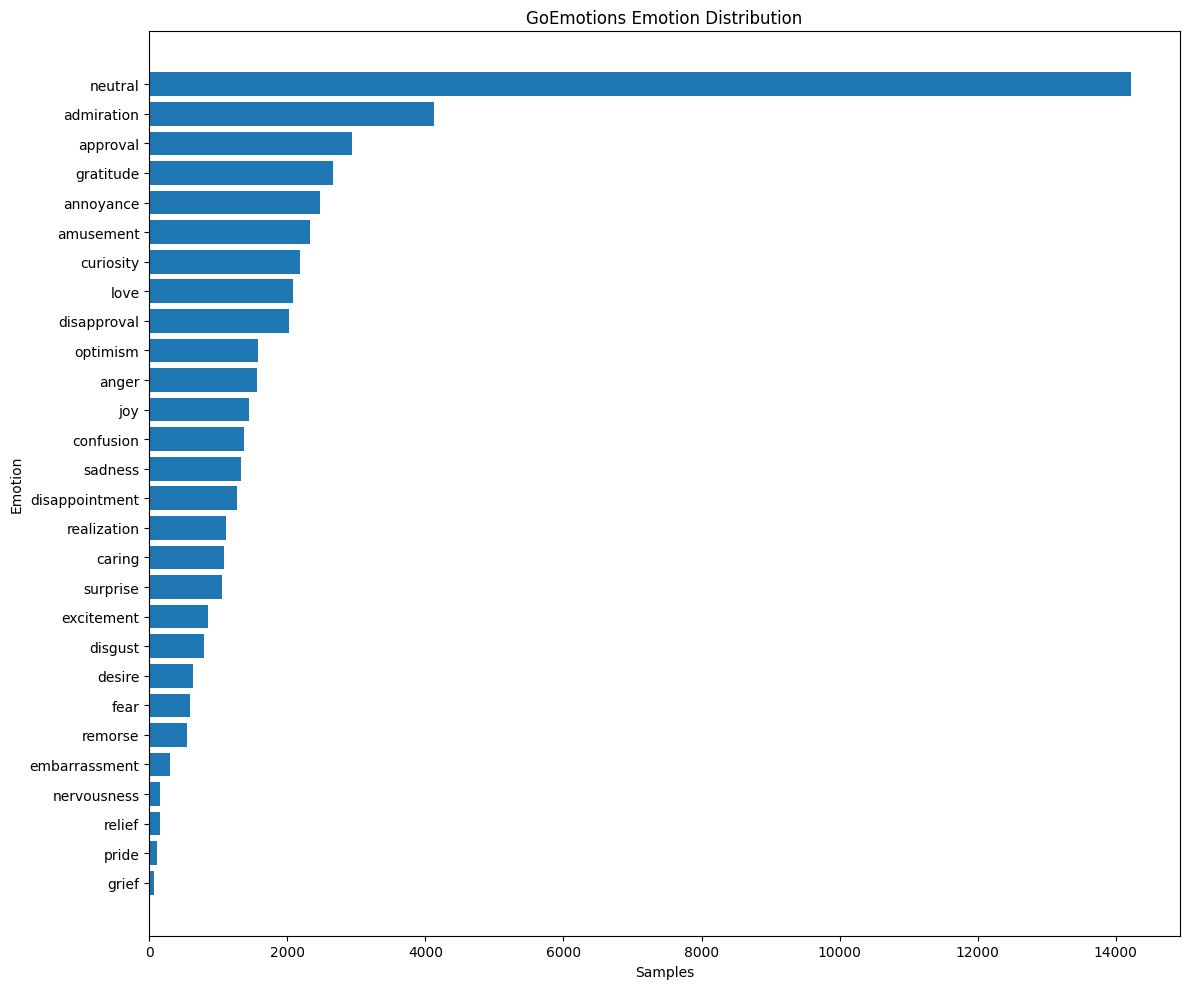

In [18]:
import matplotlib.pyplot as plt

label_counts = (
    label_counts
    .sort_values("count", ascending=True)
)

plt.figure(figsize=(12,10))

plt.barh(
    label_counts["emotion"],
    label_counts["count"]
)

plt.title(
    "GoEmotions Emotion Distribution"
)

plt.xlabel("Samples")
plt.ylabel("Emotion")

plt.tight_layout()

plt.savefig(
    "../figures/goemotions_distribution.png",
    dpi=300
)

plt.show()

In [19]:
stats = {
    "samples": len(train),
    "emotion_classes": len(emotions),
    "avg_text_length":
        train["text"].str.len().mean(),
    "max_text_length":
        train["text"].str.len().max(),
    "min_text_length":
        train["text"].str.len().min()
}

In [20]:
train["num_labels"] = (
    train["label"]
    .apply(lambda x: len(str(x).split(",")))
)

In [21]:
train["num_labels"].value_counts()

num_labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64

In [22]:
multi_label_stats = (
    train["num_labels"]
    .value_counts()
    .sort_index()
)

multi_label_stats.to_csv(
    "../data/metadata/multi_label_statistics.csv"
)